# Hierarchical calibration: a hierarchy on the physics parameters

Several experiments at different energies constrain a model whose
parameters run with energy.  If the assumed energy dependence is wrong, a
global fit under-covers everywhere.  A hierarchy on the *physics
parameters*, one deviation vector per dataset with a learned spread, repairs
the coverage, in sample and at an energy that was never fit, and it costs
nothing beyond declaring the parameters.  The eight-schools model opens the
notebook as the textbook version of the same idea.

Recipes: 22, 24, 30, 35, 38

In [1]:
import corner
import dynesty
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

import rxmc as rx

## Prologue: eight schools, non-centred

Eight estimates `y_j` with known standard errors, believed to scatter around
a common mean `μ` with spread `τ`.  In the non-centred spelling
`θ_j = μ + τ η_j` with `η_j ~ N(0, 1)`, every parameter has a marginal
prior, so nested sampling needs no joint block.  `τ` piles up near zero, as
in the book, and the `θ_j` shrink toward `μ`.

log Z = -32.11 +/- 0.19, 14976 likelihood calls


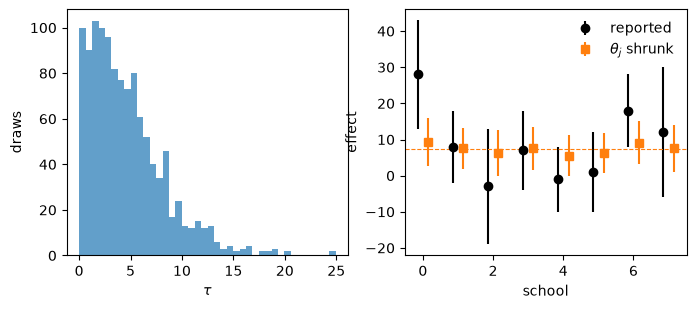

In [2]:
Y = np.array([28.0, 8.0, -3.0, 7.0, -1.0, 1.0, 18.0, 12.0])
S = np.array([15.0, 10.0, 16.0, 11.0, 9.0, 11.0, 10.0, 18.0])
schools = rx.Dataset(np.arange(8), Y, S, label="schools")
mu = rx.Parameter("mu", prior=stats.norm(0.0, 25.0), latex=r"\mu")
tau = rx.Parameter(
    "tau", prior=stats.halfnorm(scale=10.0), bounds=(0.0, np.inf), latex=r"\tau"
)
etas = [
    rx.Parameter(f"eta_{j}", prior=stats.norm(0.0, 1.0), latex=rf"\eta_{j}")
    for j in range(8)
]
school = rx.Model(lambda x, mu, tau, *eta: mu + tau * np.asarray(eta), [mu, tau, *etas])
p_schools = rx.Problem([rx.Constraint([rx.Comparison(schools, school)])])


def nested(problem, seed, nlive=200, dlogz=0.5):
    sampler = dynesty.NestedSampler(
        problem.log_likelihood,
        problem.prior_transform,
        problem.ndim,
        nlive=nlive,
        sample="rwalk",
        rstate=np.random.default_rng(seed),
    )
    sampler.run_nested(dlogz=dlogz, print_progress=False)
    res = sampler.results
    print(
        f"log Z = {res.logz[-1]:.2f} +/- {res.logzerr[-1]:.2f}, {int(np.sum(res.ncall))} likelihood calls"
    )
    return res.samples_equal(rstate=np.random.default_rng(seed))


s_schools = nested(p_schools, 0)
thetas = s_schools[:, [0]] + s_schools[:, [1]] * s_schools[:, 2:]
fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
axes[0].hist(s_schools[:, p_schools.columns(tau)], bins=40, color="C0", alpha=0.7)
axes[0].set(xlabel=r"$\tau$", ylabel="draws")
axes[1].errorbar(np.arange(8) - 0.15, Y, S, fmt="o", color="k", label="reported")
axes[1].errorbar(
    np.arange(8) + 0.15,
    thetas.mean(0),
    thetas.std(0),
    fmt="s",
    color="C1",
    label=r"$\theta_j$ shrunk",
)
axes[1].axhline(s_schools[:, 0].mean(), color="C1", ls="--", lw=0.8)
axes[1].set(xlabel="school", ylabel="effect")
axes[1].legend(frameon=False)
plt.show()

## The study: a quadratic whose coefficients run with energy

The truth is `y = a_0(E) + a_1(E) x + a_2(E) x²`, and each coefficient's
energy dependence is a smooth trend plus a non-monotonic bump.  Seven
synthetic datasets at known energies constrain it; an eighth at a new
energy between two of them is held out to test prediction.  Every dataset reports honest 3 %
errors, so the only thing that can go wrong is the model.

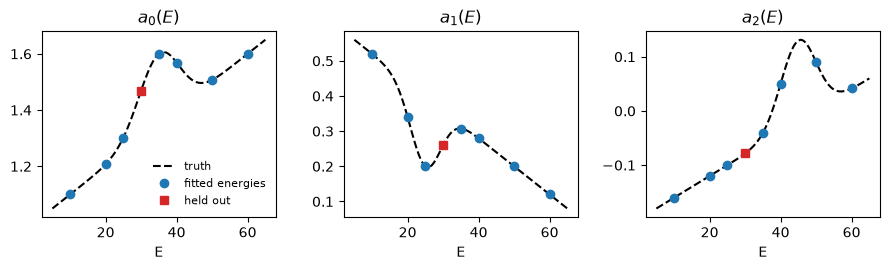

In [3]:
def a_true(E):
    return np.array(
        [
            1.0 + 0.010 * E + 0.25 * np.exp(-(((E - 35.0) / 8.0) ** 2)),
            0.6 - 0.008 * E - 0.20 * np.exp(-(((E - 25.0) / 6.0) ** 2)),
            -0.20 + 0.004 * E + 0.15 * np.exp(-(((E - 45.0) / 7.0) ** 2)),
        ]
    )


def quadratic(x, a0, a1, a2):
    return a0 + a1 * x + a2 * x**2


rng = np.random.default_rng(12)
energies = np.array([10.0, 20.0, 25.0, 35.0, 40.0, 50.0, 60.0])
E_new = 30.0
x = np.linspace(-1.0, 1.0, 12)
noise = 0.03


def dataset(E, label):
    y = quadratic(x, *a_true(E))
    return rx.Dataset(
        x,
        y + rng.normal(0.0, noise, x.size),
        np.full(x.size, noise),
        label=label,
        meta={"Elab": E},
    )


datasets = [dataset(E, f"E = {E:.0f}") for E in energies]
held_out = dataset(E_new, f"E = {E_new:.0f} (held out)")

E_grid = np.linspace(5.0, 65.0, 100)
A_grid = np.array([a_true(E) for E in E_grid])
fig, axes = plt.subplots(1, 3, figsize=(9, 2.8))
for k, ax in enumerate(axes):
    ax.plot(E_grid, A_grid[:, k], "k--", label="truth")
    ax.plot(
        energies,
        [a_true(E)[k] for E in energies],
        "o",
        color="C0",
        label="fitted energies",
    )
    ax.plot([E_new], [a_true(E_new)[k]], "s", color="C3", label="held out")
    ax.set(xlabel="E", title=f"$a_{k}(E)$")
axes[0].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## Three fits of the same data

One `Model` per comparison, closing over that dataset's energy (recipe 35);
the coefficient objects are shared, so the problem has one column per
global parameter.  The held-out comparison is part of every constraint but
fully masked: it contributes nothing to the likelihood, and any parameter
that only it uses is sampled from its prior.

1. **The correct mapping**, `a_k(E; φ) = φ_k0 + φ_k1 E + φ_k2 exp(−((E − c_k)/w_k)²)`
   with the bump centres and widths known: global `φ`.
2. **A misspecified smooth mapping**, `a_k(E; φ) = φ_k0 + φ_k1 E`: global
   `φ`, no bumps.
3. **The misspecified mapping plus a hierarchy**: per-dataset deviations
   `δ_j = τ ⊙ η_j` in parameter space, non-centred, `η_jk ~ N(0, 1)` and
   `τ_k ~ HalfNormal`, so the spread of the deviations is learned (recipes
   22, 24).  The held-out dataset gets its own `η_new`, driven by `τ`
   alone.

In [4]:
centres, widths = (35.0, 25.0, 45.0), (8.0, 6.0, 7.0)
all_data = datasets + [held_out]
masks = [np.ones(x.size, dtype=bool)] * len(datasets) + [np.zeros(x.size, dtype=bool)]


def global_params(prefix, n_per):
    return [
        [
            rx.Parameter(
                f"{prefix}{k}{i}", prior=stats.norm(0.0, 1.0), latex=rf"\phi_{{{k}{i}}}"
            )
            for i in range(n_per)
        ]
        for k in range(3)
    ]


def build(mapping, phis, hierarchy=False):
    flat = [p for ps in phis for p in ps]
    taus = [
        rx.Parameter(
            f"tau_{k}",
            prior=stats.halfnorm(scale=0.2),
            bounds=(0.0, np.inf),
            latex=rf"\tau_{k}",
        )
        for k in range(3)
    ]
    comps = []
    for j, d in enumerate(all_data):
        E = d.meta["Elab"]
        if hierarchy:
            etas = [
                rx.Parameter(f"eta_{j}_{k}", prior=stats.norm(0.0, 1.0))
                for k in range(3)
            ]

            def fn(x, *v, E=E, n=len(flat)):
                phi, tau, eta = v[:n], np.asarray(v[n : n + 3]), np.asarray(v[n + 3 :])
                return quadratic(x, *(mapping(E, phi) + tau * eta))

            model = rx.Model(fn, [*flat, *taus, *etas])
        else:

            def fn(x, *phi, E=E):
                return quadratic(x, *mapping(E, phi))

            model = rx.Model(fn, flat)
        comps.append(rx.Comparison(d, model))
    c = rx.Constraint(comps, masks=masks)
    return rx.Problem([c]), c


def correct_mapping(E, phi):
    phi = np.reshape(phi, (3, 3))
    return np.array(
        [
            phi[k, 0]
            + phi[k, 1] * E / 50.0
            + phi[k, 2] * np.exp(-(((E - centres[k]) / widths[k]) ** 2))
            for k in range(3)
        ]
    )


def linear_mapping(E, phi):
    phi = np.reshape(phi, (3, 2))
    return np.array([phi[k, 0] + phi[k, 1] * E / 50.0 for k in range(3)])


cases = {
    "1. correct mapping": build(correct_mapping, global_params("phi", 3)),
    "2. misspecified": build(linear_mapping, global_params("psi", 2)),
    "3. misspecified + hierarchy": build(
        linear_mapping, global_params("chi", 2), hierarchy=True
    ),
}
for name, (p, c) in cases.items():
    print(
        f"{name:28s} ndim = {p.ndim:2d}   active points = {c.n_active} of {c.n_total}"
    )

1. correct mapping           ndim =  9   active points = 84 of 96
2. misspecified              ndim =  6   active points = 84 of 96
3. misspecified + hierarchy  ndim = 33   active points = 84 of 96


In [5]:
samples = {
    name: nested(p, seed=i + 1, nlive=100, dlogz=1.0)
    for i, (name, (p, c)) in enumerate(cases.items())
}

log Z = 143.30 +/- 1.13, 109383 likelihood calls


log Z = -408.02 +/- 0.99, 66925 likelihood calls


log Z = 137.68 +/- 1.31, 284517 likelihood calls


## The coefficient mappings against the truth

For each case, the posterior band of `a_k(E)` over the energy range.  The
hierarchical case has two things to show: the global smooth mapping, and
the per-dataset values `a_k(E_j) + δ_jk` it actually used, which are what
track the bumps.

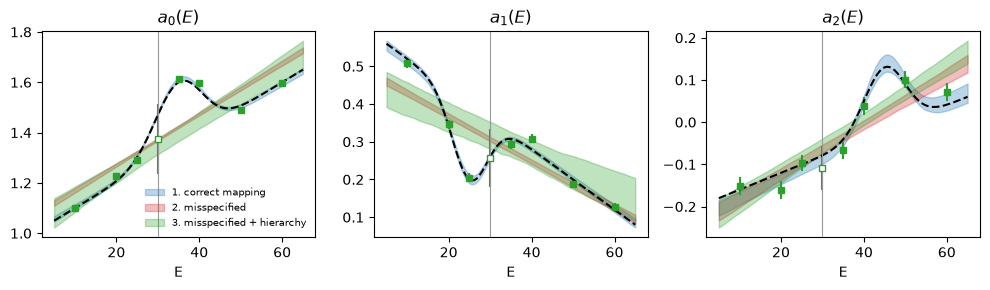

In [6]:
mappings = {
    "1. correct mapping": correct_mapping,
    "2. misspecified": linear_mapping,
    "3. misspecified + hierarchy": linear_mapping,
}
colors = {
    "1. correct mapping": "C0",
    "2. misspecified": "C3",
    "3. misspecified + hierarchy": "C2",
}
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for name, (p, c) in cases.items():
    s = samples[name][::10]
    n_phi = 9 if name.startswith("1") else 6
    curves = np.array([[mappings[name](E, row[:n_phi]) for E in E_grid] for row in s])
    lo, hi = np.percentile(curves, [16, 84], axis=0)
    for k, ax in enumerate(axes):
        ax.fill_between(
            E_grid, lo[:, k], hi[:, k], color=colors[name], alpha=0.3, label=name
        )
    if name.startswith("3"):
        tau_cols, eta_cols = (
            p.columns([q for q in p.params if q.name.startswith("tau")]),
            None,
        )
        for j, E in enumerate(list(energies) + [E_new]):
            cols_eta = p.columns(
                [q for q in p.params if q.name.startswith(f"eta_{j}_")]
            )
            local = np.array(
                [
                    linear_mapping(E, row[:6]) + row[tau_cols] * row[cols_eta]
                    for row in s
                ]
            )
            for k, ax in enumerate(axes):
                ax.errorbar(
                    [E],
                    [local[:, k].mean()],
                    [local[:, k].std()],
                    fmt="s",
                    ms=4,
                    color="C2",
                    mfc="w" if j == len(energies) else "C2",
                )
for k, ax in enumerate(axes):
    ax.plot(E_grid, A_grid[:, k], "k--")
    ax.axvline(E_new, color="0.6", lw=0.8)
    ax.set(xlabel="E", title=f"$a_{k}(E)$")
axes[0].legend(frameon=False, fontsize=7)
plt.tight_layout()
plt.show()

## Residuals of the misspecified fit

Case 2 leaves structured, dataset-by-dataset residuals: the smooth mapping
is right on average and wrong at every energy.

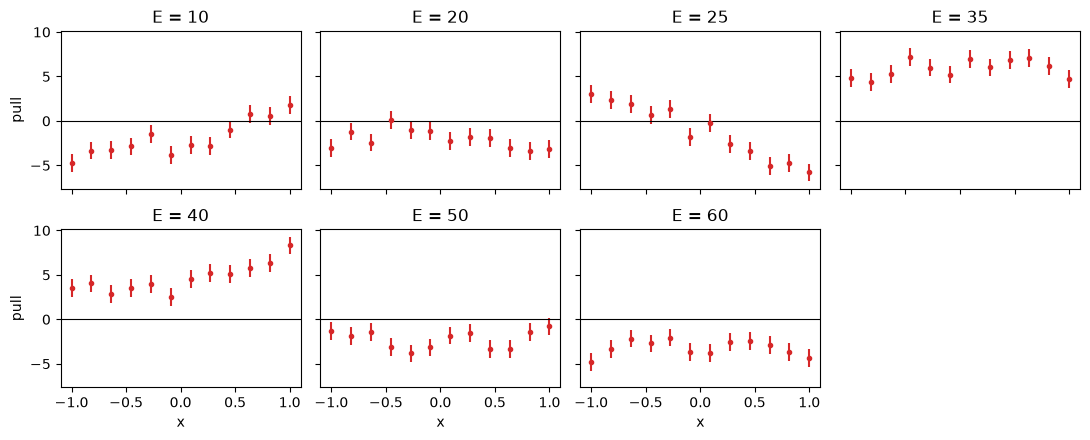

In [7]:
p2, c2 = cases["2. misspecified"]
ym2 = p2.predict(np.median(samples["2. misspecified"], axis=0))[0]
fig, axes = plt.subplots(2, 4, figsize=(11, 4.5), sharex=True, sharey=True)
axes.ravel()[-1].axis("off")
for ax, d, ym in zip(axes.ravel(), datasets, ym2):
    ax.errorbar(d.x, (d.y - ym) / d.y_err, 1.0, fmt="o", ms=3, color="C3")
    ax.axhline(0, color="k", lw=0.8)
    ax.set(title=d.label)
for ax in axes[-1]:
    ax.set(xlabel="x")
for ax in axes[:, 0]:
    ax.set(ylabel="pull")
plt.tight_layout()
plt.show()

## Coverage, in sample and at the held-out energy

`predictive_draws` on the fitted problem gives the in-sample posterior
predictive; on `Problem([c.complement()])`, the same parameters and terms
with the held-out points active, it gives the prediction at the new energy,
with no extra code.  For the hierarchical case that prediction includes the
prior-sampled `η_new` scaled by the learned `τ`: a scale mixture, wider and
longer-tailed than in sample.

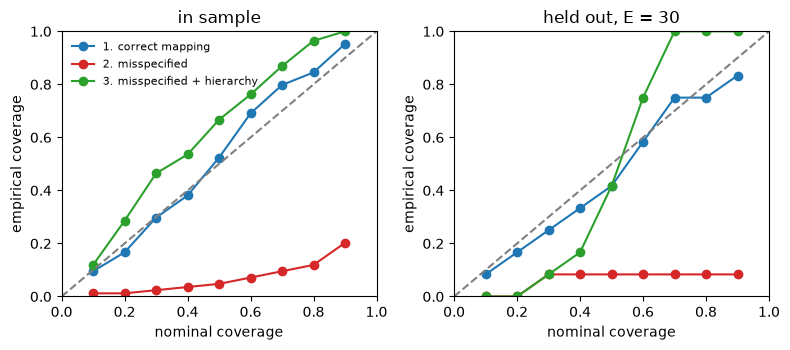

case                         held-out log predictive   68 % predictive width
1. correct mapping                 24.8                0.062
2. misspecified                   -21.9                0.060
3. misspecified + hierarchy        20.4                0.286


In [8]:
levels = np.linspace(0.1, 0.9, 9)
fig, axes = plt.subplots(1, 2, figsize=(8, 3.6))
scores = {}
for name, (p, c) in cases.items():
    s = samples[name]
    held = rx.Problem([c.complement()])
    draws_in = rx.diagnostics.predictive_draws(p, s[::10], n_rep=2, rng=1)
    draws_out = rx.diagnostics.predictive_draws(held, s[::10], n_rep=2, rng=2)
    ci, ch = p.constraints[0], held.constraints[0]
    axes[0].plot(
        levels,
        rx.diagnostics.coverage_curve(draws_in, ci.y[ci.active], levels),
        "o-",
        color=colors[name],
        label=name,
    )
    axes[1].plot(
        levels,
        rx.diagnostics.coverage_curve(draws_out, ch.y[ch.active], levels),
        "o-",
        color=colors[name],
        label=name,
    )
    scores[name] = (
        rx.diagnostics.log_posterior_predictive(
            rx.diagnostics.heldout_log_predictive(held, s[::5])
        ),
        rx.diagnostics.sharpness(draws_out).mean(),
    )
for ax, title in zip(axes, ("in sample", f"held out, E = {E_new:.0f}")):
    ax.plot([0, 1], [0, 1], "--", color="0.5")
    ax.set(
        xlabel="nominal coverage",
        ylabel="empirical coverage",
        title=title,
        xlim=(0, 1),
        ylim=(0, 1),
    )
axes[0].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()
print(f"{'case':28s} held-out log predictive   68 % predictive width")
for name, (lp, width) in scores.items():
    print(f"{name:28s} {lp:10.1f}                {width:.3f}")

## The learned spread

The posterior of `τ` is away from zero in the hierarchical case: the data
asked for per-dataset deviations of a definite size, which is the
misspecification made visible.

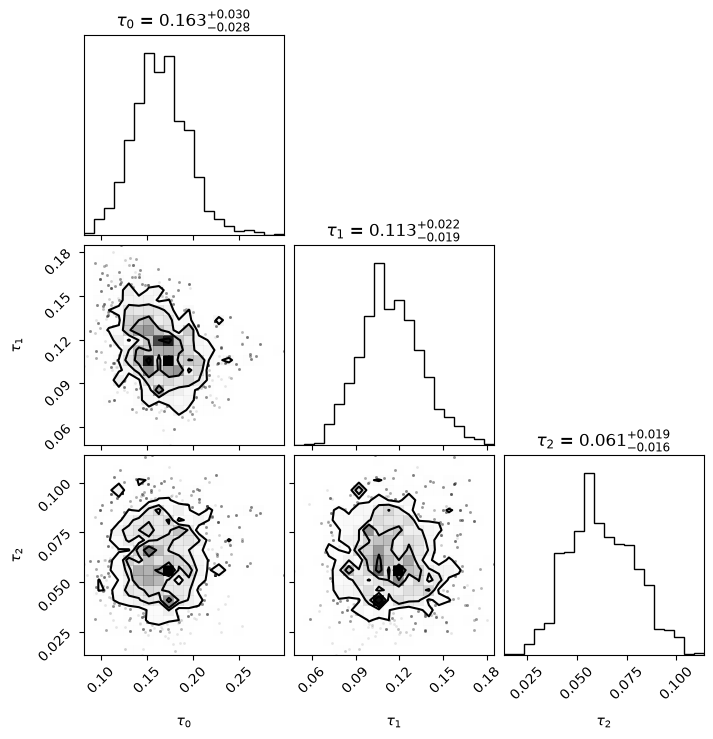

In [9]:
p3, _ = cases["3. misspecified + hierarchy"]
s3 = samples["3. misspecified + hierarchy"]
tau_params = [q for q in p3.params if q.name.startswith("tau")]
fig = corner.corner(
    s3[:, p3.columns(tau_params)],
    labels=[f"${q.latex}$" for q in tau_params],
    show_titles=True,
    title_fmt=".3f",
)
plt.show()

## Takeaways

- The correct mapping covers in sample and out of sample.  The misspecified
  smooth mapping under-covers both and leaves structured residuals at every
  energy.
- The hierarchy on the physics parameters recovers the coverage with wider,
  longer-tailed bands at the new energy, a `τ` posterior away from zero,
  and the better held-out score of the two misspecified fits.
- A parameter attached only to a fully masked comparison is sampled from
  its prior.  That is the whole mechanism for predicting a new dataset:
  `complement()`, `predictive_draws` and `heldout_log_predictive` score
  the new energy with no extra code.
- With few datasets the global `φ` and the deviations `δ_j` trade off, and
  the hyperprior on `τ` is what resolves it.